# Correlation
### CA2 @ EPS Course

#### Instructors: Dr. Tavassolipour, Dr. Vahabie

---

### Instructions:
-  Replace the placeholders (between <font color="green">`## TODO ##`</font> and <font color="green">`## TODO ##`</font>) with the appropriate details.
- Ensure you run each cell after you've entered your solution.

---

*Full Name:* ...

*SID:* ...

The objective of this notebook is to understand the concept of correlation.


In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

## Calculate Correlation
complete `correlation` function that calculate the correlation matrix of a data fram.

**Note:** you are not allowed to use `pandas.core.frame.DataFrame.corr()` method

In [2]:
def correlation(data: pd.DataFrame) -> pd.DataFrame:
    """
    Calculates the correlation matrix from a given dataset.

    Args:
        data (pandas.core.frame.DataFrame): The dataset, where each row represents an observation and each column represents a feature.

    Returns:
        correlation_matrix (pandas.core.frame.DataFrame): The correlation matrix.
    """
    ######################  TODO  ########################
    correlation_matrix = pd.DataFrame(index = data.keys(), columns = data.keys())
    data_normalized = data.copy()
    size = data.shape[0]
    
    data_normalized = (data - data.mean()) / data.std()
    
    for i in data_normalized:
        for j in data_normalized:
            correlation_matrix.loc[i, j] = np.dot(data_normalized[i], data_normalized[j]) * (1/(size - 1))
                        
    return correlation_matrix
    ######################  TODO  ########################

In [3]:
######################  TODO  ########################
energies = pd.read_csv("data/energy.csv")
######################  TODO  ########################

### Convert to Datetime and Extract Features

In [4]:
######################  TODO  ########################
energies["Datetime"] = pd.to_datetime(energies["Datetime"])
energies["Year"] = energies["Datetime"].dt.year
energies["Month"] = energies["Datetime"].dt.month
energies["Day"] = energies["Datetime"].dt.day
energies["Hour"] = energies["Datetime"].dt.hour
######################  TODO  ########################

### Plot Energy Usage Over Years

<Axes: xlabel='Year', ylabel='AEP_MW'>

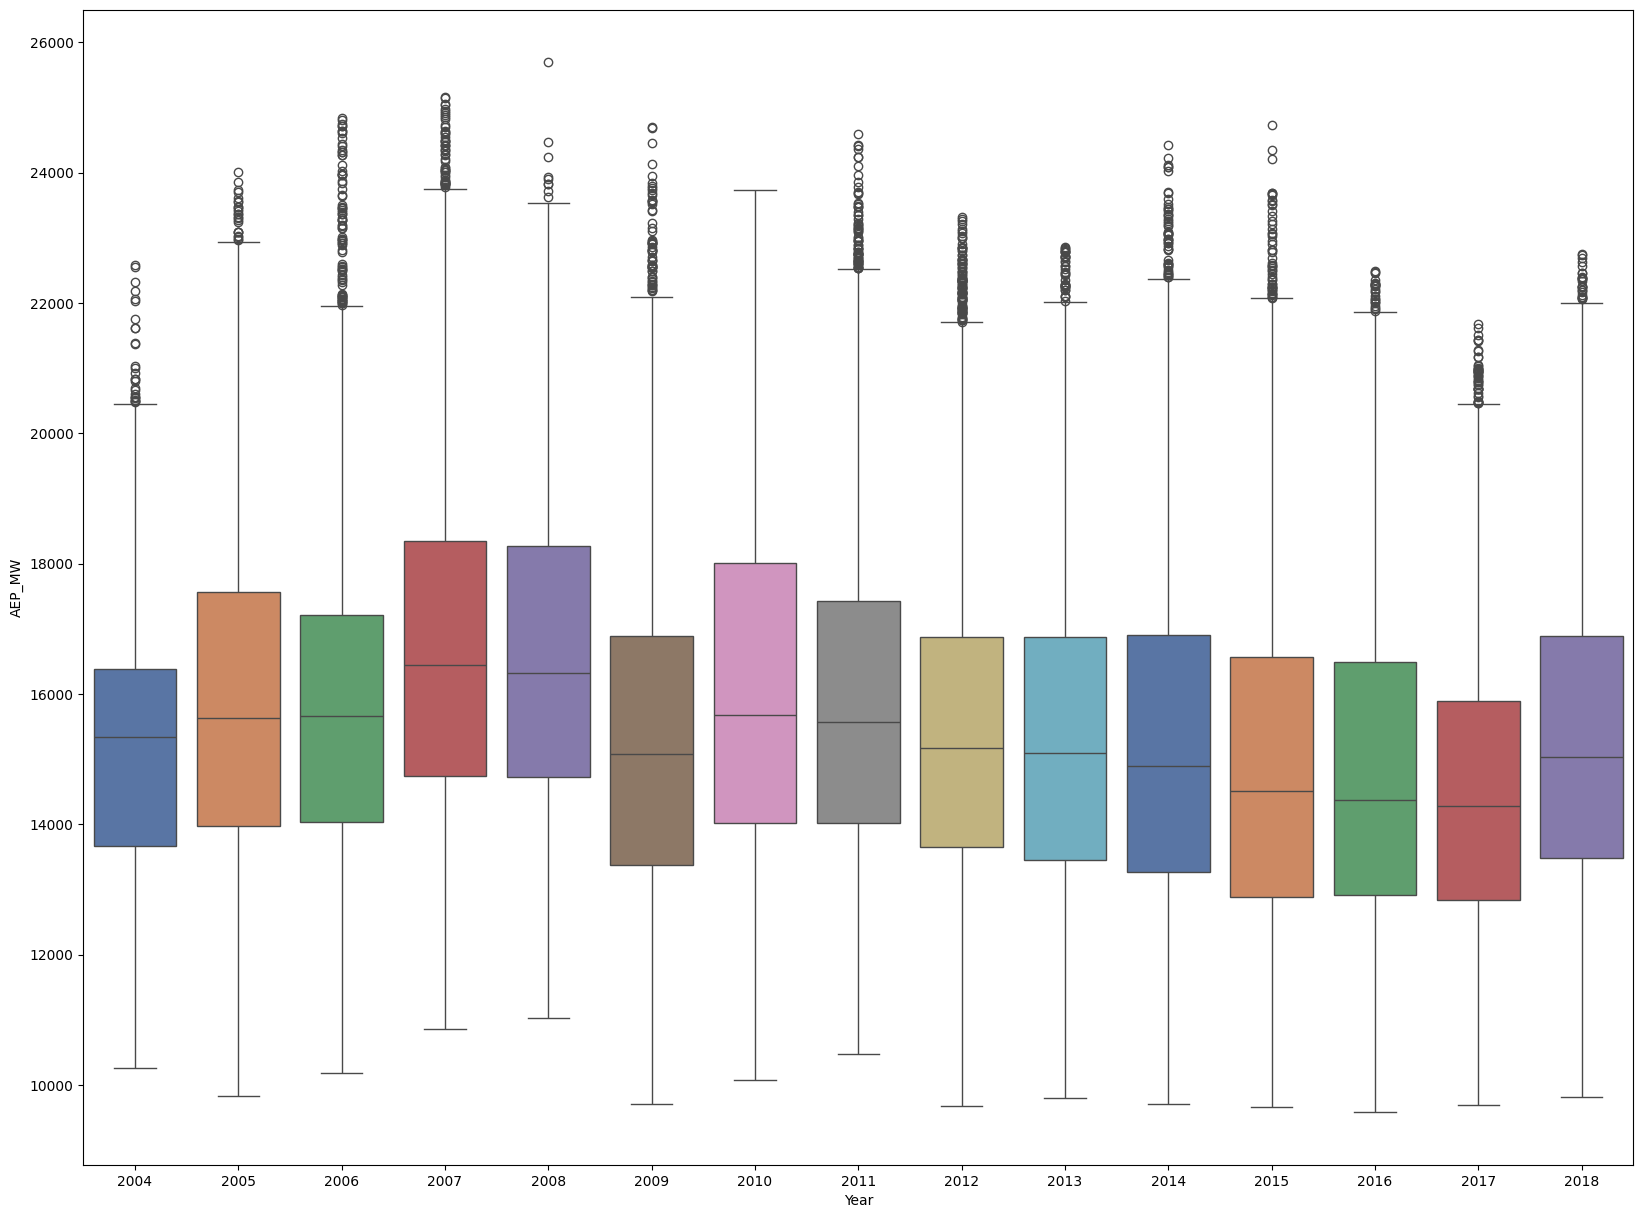

In [17]:
######################  TODO  ########################
plt.figure(figsize=(20, 15))
sns.boxplot(x = "Year", y = "AEP_MW", data = energies, palette="deep")
######################  TODO  ########################

### Analyze Energy Usage Over Years

As we can see in the plot, the length of the box and the bar is more in 2005 year. This means the data has a wider range and the variance of power consumption in 2005 is more than 2004.

In [20]:
######################  TODO  ########################
energies_2004 = energies[energies["Datetime"].dt.year == 2004]
energies_2005 = energies[energies["Datetime"].dt.year == 2005]
print(f"The variance for the year 2004 is {energies_2004["AEP_MW"].var()} and for 2005 is {energies_2005["AEP_MW"].var()}")
######################  TODO  ########################

The variance for the year 2004 is 4312554.64327797 and for 2005 is 6609516.545765586


### Plot Energy Usage Over Hours

<Axes: xlabel='Hour', ylabel='AEP_MW'>

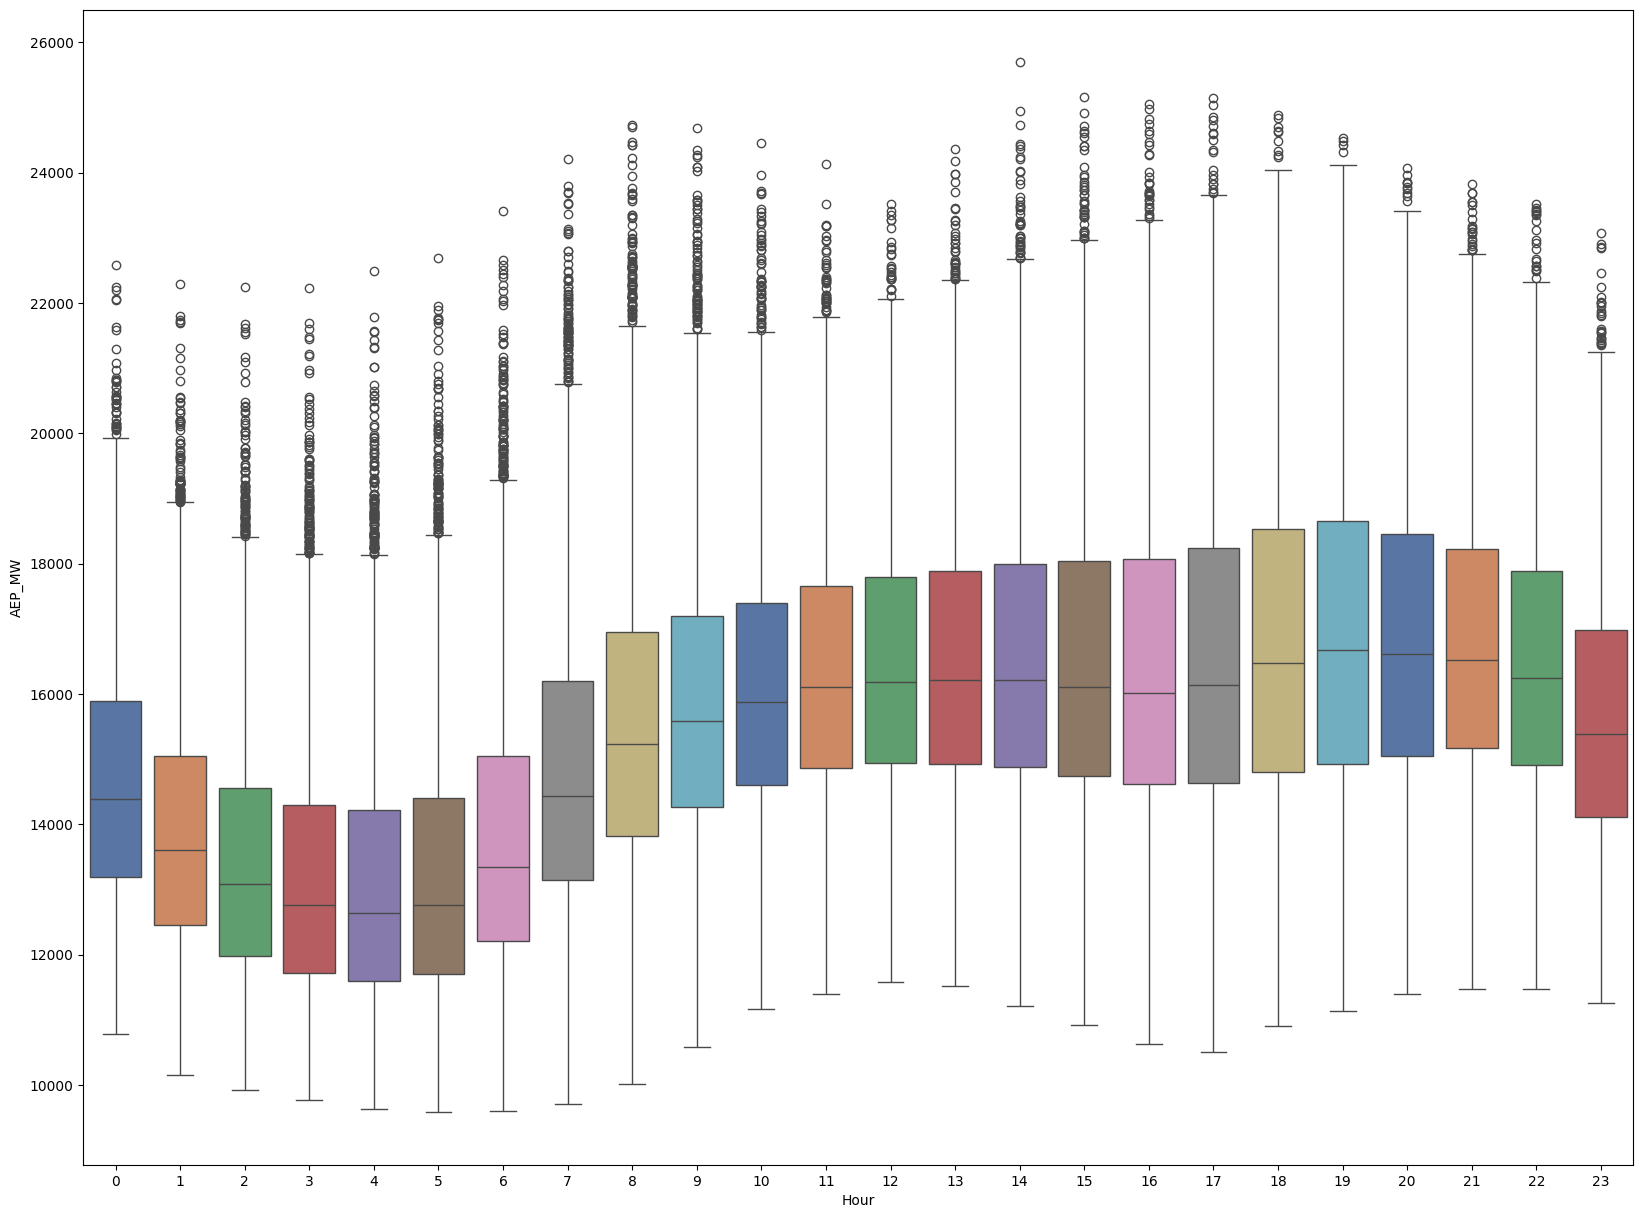

In [22]:
######################  TODO  ########################
plt.figure(figsize=(20, 15))
sns.boxplot(x = "Hour", y = "AEP_MW", data = energies, palette="deep")
######################  TODO  ########################

As we could predict, the peak of power consumption during a day is between times 18:00 and 22:00 especially between 18:00 and 20:00. This is intuitively correct; because at this time people need lights and have come home from work so they need more energy for their chores arround the house.

And also arround the times 2:00 to 6:00 is the least power consumption of the day. It's obviously becuase the people are mostly asleep then :)

### Plot Energy Usage Over Months

<Axes: xlabel='Month', ylabel='AEP_MW'>

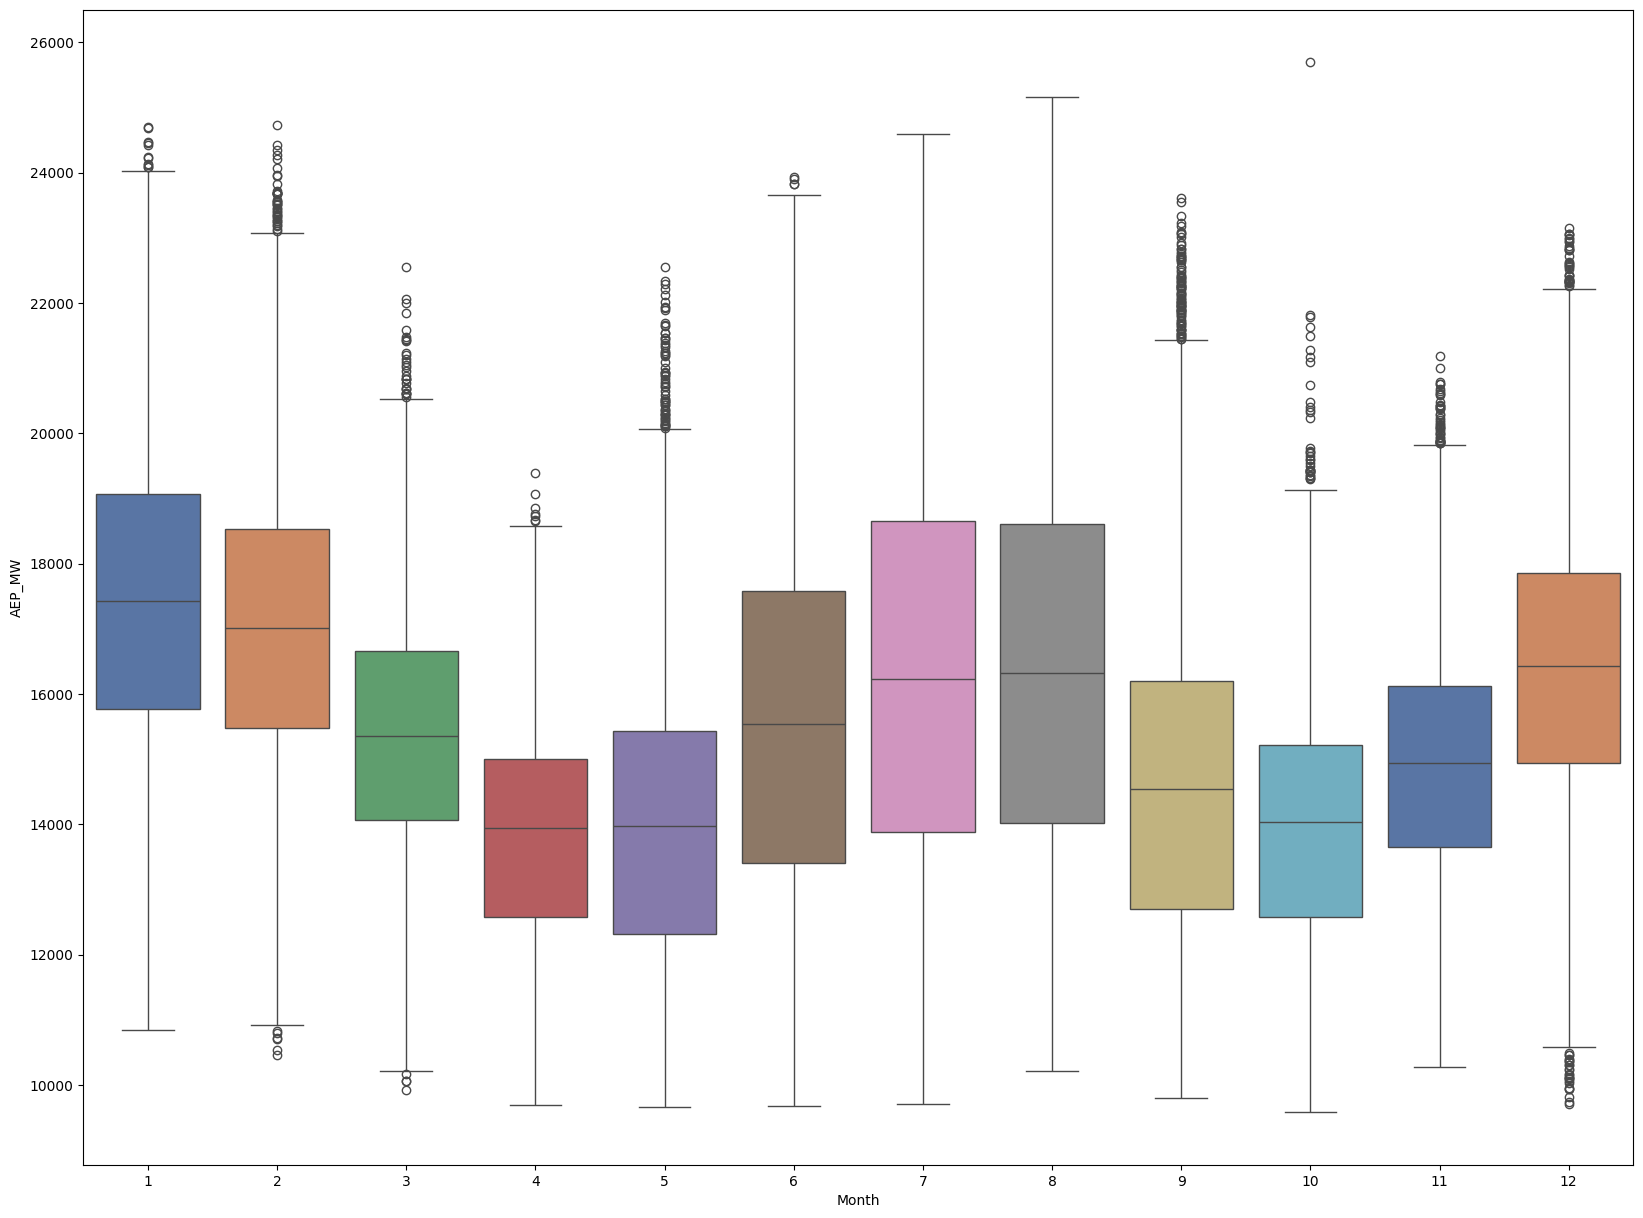

In [ ]:
######################  TODO  ########################
plt.figure(figsize=(20, 15))
sns.boxplot(x = "Month", y = "AEP_MW", data = energies, palette = "deep")
######################  TODO  ########################

To analyze I can say that the power consumption in more in the hot and cold seasons(summer and winter) because of using heating and cooling devices more. Months 12, 1 and 2 are for winter season and months 6, 7 and 8 are for summer season and it's obvious that the power consumption is more in those months. 

### Calculate Correlation Between Specific Hours and Energy Usage

In [31]:
######################  TODO  ########################
filtered_time_energies = energies[(energies["Hour"] >= 4) & (energies["Hour"] <= 13)]
correlation_matrix = correlation(filtered_time_energies)
print(correlation_matrix)
######################  TODO  ########################

          Datetime    AEP_MW      Year     Month       Day      Hour
Datetime       1.0 -0.187235  0.997389  -0.02178   0.00496  0.000092
AEP_MW   -0.187235       1.0 -0.173237 -0.185336 -0.007668  0.471379
Year      0.997389 -0.173237       1.0 -0.093674 -0.001817  0.000006
Month     -0.02178 -0.185336 -0.093674       1.0  0.010586  0.000049
Day        0.00496 -0.007668 -0.001817  0.010586       1.0 -0.000034
Hour      0.000092  0.471379  0.000006  0.000049 -0.000034       1.0


### Analyze Correlation Between Specific Hours and Energy Usage

This matrix shows that the correlation coefficient between power consumption and the hour is 0.471379. As we can se on the boxplots, although the relationship between hour and power consumption between 4 and 13 is ascending, it's not linear. So the correlation coeffiecient is more than 0 but not close to 1.


### Calculate Correlation Between Specific Months and Energy Usage

In [41]:
######################  TODO  ########################
filtered_month_energies_2to4 = energies[(energies["Month"] >= 2) & (energies["Month"] <= 4)]
filtered_month_energies_10to12 = energies[(energies["Month"] >= 10) & (energies["Month"] <= 12)]

correlation_matrix_1 = correlation(filtered_month_energies_2to4)
correlation_matrix_2 = correlation(filtered_month_energies_10to12)

print(correlation_matrix_1)
print("____________________________________________________________________")
print(correlation_matrix_2)
######################  TODO  ########################

          Datetime    AEP_MW      Year     Month       Day      Hour
Datetime       1.0 -0.235836  0.999847  0.016241  0.006873  0.000187
AEP_MW   -0.235836       1.0 -0.225727 -0.558245 -0.188948  0.252592
Year      0.999847 -0.225727       1.0 -0.000253  0.000377 -0.000008
Month     0.016241 -0.558245 -0.000253       1.0  0.040864  0.000088
Day       0.006873 -0.188948  0.000377  0.040864       1.0 -0.000382
Hour      0.000187  0.252592 -0.000008  0.000088 -0.000382       1.0
____________________________________________________________________
          Datetime    AEP_MW      Year     Month       Day      Hour
Datetime       1.0 -0.246838  0.999837  0.016768  0.005887 -0.000328
AEP_MW   -0.246838       1.0  -0.25507  0.473838  0.012558  0.361968
Year      0.999837  -0.25507       1.0 -0.000235 -0.000124 -0.000521
Month     0.016768  0.473838 -0.000235       1.0  0.000193  -0.00012
Day       0.005887  0.012558 -0.000124  0.000193       1.0 -0.000125
Hour     -0.000328  0.361968 -0.00

### Analyze Correlation Between Specific Hours and Energy Usage

As we can see in the correlation matrix, the correlation coefficient between month number and power consumption between the months 2 and 4 is -0.558245 and between the months 10 and 12 is 0.473838. This is justifiable by thinking about the months and their seasons. 

Winter is the months 12, 1 and 2. So since 2 to 4 it is getting warmer and and the weather is becoming balanced so people won't need heating and cooling devices. This lowers the power consumption and as a result the correlation coefficient will be negative. 

Also about the second coefficient, we can say it starts from a balanced temperature in the autumn and the more time passes the colder it gets. So people will need more and more power to provide for heating devices and because of that the correlation coefficient will be positive.

## Causal Effect

In [48]:
######################  TODO  ########################
life_expectancies = pd.read_csv("data/TV_LE_Physician.csv")
life_expectancies = life_expectancies.drop("Country", axis = 1)
print(correlation(life_expectancies))
######################  TODO  ########################

                            Life Expectancy (years)  \
Life Expectancy (years)                         1.0   
Physicians per 1000 people                 0.628805   
Televisions per 1000 people                0.025875   

                            Physicians per 1000 people  \
Life Expectancy (years)                       0.628805   
Physicians per 1000 people                         1.0   
Televisions per 1000 people                   0.008602   

                            Televisions per 1000 people  
Life Expectancy (years)                        0.025875  
Physicians per 1000 people                     0.008602  
Televisions per 1000 people                         1.0  


All of the correlation coefficients between "Televisions per 1000 people" variable and other variables is approximately 0. so there is no causal relationship between this variable and the others.

But between the "Physicians per 1000 people" and "Life Expectancy (years)" variables, the correlation coefficient equals 0.628805 which is considerable. There is a causation here. The more doctors we have the healthier people are and the healther they are the more they live! So I guess there is a causal effect here which is obvious.